# PONTIFICIA UNIVERSIDAD JAVERIANA

## ENTREGA FINAL PROYECTO - PARCIAL 3

### PROCESAMIENTO DE DATOS A GRAN ESCALA

**INTEGRANTES** 
- SARA JULIANA PEÑA GÓMEZ
- DANIELA FLOREZ
- SANTIAGO RIVEROS


In [0]:
#Se importan las librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import random
from pyspark import SparkFiles
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.sql import SQLContext
from pyspark.sql.session import SparkSession
from pyspark.sql.types import IntegerType, FloatType, DoubleType, StringType
from pyspark.sql.functions import mean, col, split, when, isnan, count, udf, lit, to_date, concat, split, desc, month, avg, max, min, sum, upper, lower, current_date, date_add, datediff, round, stddev
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql import Window
import pyspark.sql.functions as F
from collections import defaultdict

### Se cargan los conjuntos de datos
- Personas (pobreza)
- Internet por municipio
- Educación por secciones
- Saber Icfes 2019
### Se les asigna variables para identificar cada uno

In [0]:
#DataFrame de Personas
urlPersonas = "https://raw.githubusercontent.com/Sarapena02/Procesamiento-de-alto-volumenes-de-datos/refs/heads/main/Conjunto_Datos/Personas%20(%20Departamental%20)%202020.csv"
spark.sparkContext.addFile(urlPersonas)
file_name ="Personas ( Departamental ) 2020.csv"
path1 = SparkFiles.get(file_name)
df_Personas = spark.read.csv("file://" + path1, inferSchema=True, header=True, sep=",")
df_Personas.show(10)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|DIRECTORIO;SECUENCIA_ENCUESTA;SECUENCIA_P;ORDEN;P6020;P6040;fex_c;P6051;P6090;P5665;P8563;P51;P55;P774;P6160;P8586;P8587;P8587S1;P1088;P1088S1;P6180;P6240;P6250;P6260;P6270;P6351;P6390;P7250;P6920|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                                                                                7247300;1;1;1;2;7...|
|                                                                                                                                                                                7247300;2;1;2;1;6...|
|    

In [0]:
urlInternet = "https://raw.githubusercontent.com/Sarapena02/Procesamiento-de-alto-volumenes-de-datos/refs/heads/main/Conjunto_Datos/Internet_Fijo_Penetraci_n_Municipio_20240828.csv"
spark.sparkContext.addFile(urlInternet)
file_name ="Internet_Fijo_Penetraci_n_Municipio_20240828.csv"
path2 = SparkFiles.get(file_name)
df_Internet = spark.read.csv("file://" + path2, inferSchema=True, header=True, sep=",")
df_Internet.show(10)

+----+---------+----------------+------------+-------------+---------+----------------------------+--------------+------+
| AÑO|TRIMESTRE|COD_DEPARTAMENTO|DEPARTAMENTO|COD_MUNICIPIO|MUNICIPIO|No. ACCESOS FIJOS A INTERNET|POBLACIÓN DANE|INDICE|
+----+---------+----------------+------------+-------------+---------+----------------------------+--------------+------+
|2023|        2|               5|   ANTIOQUIA|         5353| HISPANIA|                         495|          5790|  8,55|
|2023|        1|              17|      CALDAS|        17001|MANIZALES|                      102906|        454494| 22,64|
|2023|        1|              52|      NARIÑO|        52356|  IPIALES|                       11312|        120842|  9,36|
|2022|        4|              27|       CHOCÓ|        27160| CÉRTEGUI|                         179|          5967|  3,00|
|2022|        3|              15|      BOYACÁ|        15740|SIACHOQUE|                         116|          7056|  1,64|
|2022|        2|        

In [0]:
urlEducacion = "https://raw.githubusercontent.com/Sarapena02/Procesamiento-de-alto-volumenes-de-datos/refs/heads/main/Conjunto_Datos/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR__B_SICA_Y_MEDIA_POR_MUNICIPIO_20240829.csv"
spark.sparkContext.addFile(urlEducacion)
file_name ="MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR__B_SICA_Y_MEDIA_POR_MUNICIPIO_20240829.csv"
path3 = SparkFiles.get(file_name)
df_Educacion = spark.read.csv("file://" + path3, inferSchema=True, header=True, sep=",")
df_Educacion.show(10)

+----+----------------+-----------+-------------------+------------+----------+---------------+--------------+-----------------------+--------------+-------------------------+-----------------------+-------------------------+--------------------+---------------+--------------------------+------------------------+--------------------------+---------------------+------------------------+---------------------------+---------+--------------------+------------------+--------------------+---------------+----------+---------------------+-------------------+---------------------+----------------+-----------+----------------------+--------------------+----------------------+-----------------+----------+---------------------+-------------------+---------------------+----------------+
| AÑO|CÓDIGO_MUNICIPIO|  MUNICIPIO|CÓDIGO_DEPARTAMENTO|DEPARTAMENTO|CÓDIGO_ETC|            ETC|POBLACIÓN_5_16|TASA_MATRICULACIÓN_5_16|COBERTURA_NETA|COBERTURA_NETA_TRANSICIÓN|COBERTURA_NETA_PRIMARIA|COBERTURA_NETA_S

In [0]:

df_Saber = spark.read.format("csv").option("header", "true").load("dbfs:/FileStore/tables/Saber_11__2019_2_20240829__1_.csv")
df_Saber.show(10)

+------------------+-----------------+-----------+--------------------+-------+----------------+---------------+---------------+----------------+--------------------+-----------------+---------------------+-------------------+---------------------+--------------------+------------------+-----------------+--------------------+--------------------+----------------------+----------------------+------------------+--------------------+--------------------+------------------+------------------------+-------------------+---------------------+----------------------------+-----------------+-----------------------+--------------------------+-----------------------------+-----------------------+----------------------------+-----------------------+-----------------------+---------------------+-----------------+-----------------------------+---------------------------+-----------+---------------+---------------+-------------+-----------------+------------------+--------------------+----------------

# Filtros y Transformaciones

## Personas
Se le haran las siguientes transformaciones:
 - Seleccionar unicamente las columnas importantes
 - Renombrar algunas de esas columnas
 - Se encuentran los valores nulos y se hace el manejo correspondiente

In [0]:
#Personas
#Cuando se cargo el conjunto de datos, nos dimos cuenta que se esta tomando como una misma variable todos. Por ende se realizará un ciclo que separe las variables para poder hacer el cambio de variable
columnas = ["DIRECTORIO", "SECUENCIA_ENCUESTA", "SECUENCIA_P", "ORDEN", "P6020", "P6040", "fex_c", 
            "P6051", "P6090", "P5665", "P8563", "P51", "P55", "P774", "P6160", "P8586", 
            "P8587", "P8587S1", "P1088", "P1088S1", "P6180", "P6240", "P6250", "P6260", 
            "P6270", "P6351", "P6390", "P7250", "P6920"]
df_Personas1 = df_Personas.select([split(df_Personas[df_Personas.columns[0]], ';')[i].alias(columnas[i]) for i in range(len(columnas))])
df_Personas1.show()

+----------+------------------+-----------+-----+-----+-----+-----+-----+-----+-----+-----+----+----+----+-----+-----+-----+-------+-----+-------+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|DIRECTORIO|SECUENCIA_ENCUESTA|SECUENCIA_P|ORDEN|P6020|P6040|fex_c|P6051|P6090|P5665|P8563| P51| P55|P774|P6160|P8586|P8587|P8587S1|P1088|P1088S1|P6180|P6240|P6250|P6260|P6270|P6351|P6390|P7250|P6920|
+----------+------------------+-----------+-----+-----+-----+-----+-----+-----+-----+-----+----+----+----+-----+-----+-----+-------+-----+-------+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|   7247300|                 1|          1|    1|    2|   71|  513| null| null| null| null|null|null|null| null| null| null|   null| null|   null| null| null| null| null| null| null| null| null| null|
|   7247300|                 2|          1|    2|    1|   67|  513| null| null| null| null|null|null|null| null| null| null|   null| null|   null| null| null| null| null| null| null| null| null| n

In [0]:
#Se hace el cambio de nombre a la variable "P6020" a "Sexo"
#Solo nos interesa hacer el cambio de nombre de esta variable ya que el resto de variables son preguntas o cuentan con caracteres especiales que pueden dificultar el manejo del DF. 
df_Personas2 = df_Personas1.withColumnRenamed("P6020", "Sexo")
df_Personas2.show()

+----------+------------------+-----------+-----+----+-----+-----+-----+-----+-----+-----+----+----+----+-----+-----+-----+-------+-----+-------+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|DIRECTORIO|SECUENCIA_ENCUESTA|SECUENCIA_P|ORDEN|Sexo|P6040|fex_c|P6051|P6090|P5665|P8563| P51| P55|P774|P6160|P8586|P8587|P8587S1|P1088|P1088S1|P6180|P6240|P6250|P6260|P6270|P6351|P6390|P7250|P6920|
+----------+------------------+-----------+-----+----+-----+-----+-----+-----+-----+-----+----+----+----+-----+-----+-----+-------+-----+-------+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|   7247300|                 1|          1|    1|   2|   71|  513| null| null| null| null|null|null|null| null| null| null|   null| null|   null| null| null| null| null| null| null| null| null| null|
|   7247300|                 2|          1|    2|   1|   67|  513| null| null| null| null|null|null|null| null| null| null|   null| null|   null| null| null| null| null| null| null| null| null| null|


In [0]:
#Se encuentran los valores nulos del dataframe
df_Personas2.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Personas2.columns]).show()

+----------+------------------+-----------+-----+----+-----+-----+------+------+------+------+------+------+------+------+------+------+-------+------+-------+------+------+------+------+------+------+------+------+------+
|DIRECTORIO|SECUENCIA_ENCUESTA|SECUENCIA_P|ORDEN|Sexo|P6040|fex_c| P6051| P6090| P5665| P8563|   P51|   P55|  P774| P6160| P8586| P8587|P8587S1| P1088|P1088S1| P6180| P6240| P6250| P6260| P6270| P6351| P6390| P7250| P6920|
+----------+------------------+-----------+-----+----+-----+-----+------+------+------+------+------+------+------+------+------+------+-------+------+-------+------+------+------+------+------+------+------+------+------+
|         0|                 0|          0|    0|   0|    0|    0|267085|267085|267085|267085|267085|267085|267085|267085|267085|267085| 267085|267085| 267085|267085|267085|267085|267085|267085|267085|267085|267085|267085|
+----------+------------------+-----------+-----+----+-----+-----+------+------+------+------+------+------+

In [0]:
df_Personas3 = df_Personas1.select(
    df_Personas1["P6020"].alias("Sexo"),
    df_Personas1["P6040"],
    df_Personas1["P6160"],
    df_Personas1["P8587"]
)
df_Personas3.show()

+----+-----+-----+-----+
|Sexo|P6040|P6160|P8587|
+----+-----+-----+-----+
|   2|   71| null| null|
|   1|   67| null| null|
|   1|   64| null| null|
|   1|   84| null| null|
|   2|   76| null| null|
|   1|   59| null| null|
|   2|   56| null| null|
|   1|   27| null| null|
|   1|   24| null| null|
|   1|    7| null| null|
|   2|   75| null| null|
|   2|   48| null| null|
|   1|   21| null| null|
|   1|   15| null| null|
|   2|   10| null| null|
|   1|   35| null| null|
|   2|   29| null| null|
|   1|    8| null| null|
|   1|    0| null| null|
|   2|   28| null| null|
+----+-----+-----+-----+
only showing top 20 rows



In [0]:
#Se encuentran los valores nulos del dataframe
df_Personas3.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Personas3.columns]).show()

+----+-----+------+------+
|Sexo|P6040| P6160| P8587|
+----+-----+------+------+
|   0|    0|267085|267085|
+----+-----+------+------+



## Internet
Se le haran las siguientes transformaciones:

- Seleccionar unicamente las columnas importantes
- Renombrar algunas de esas columnas
- Se encuentran los valores nulos y se hace el manejo correspondiente
- Se realiza un filtrado de los departamentos que nos interesan

In [0]:
# Se hara el cambio de nombre a las variables
nuevasColumnas = ['ANIO', 'TRIMESTRE', 'COD_DEPT', 'DEPARTAMENTO', 'COD_MUN', 'MUNICIPIO', 'No_ACCESOS_FIJOS_A_INTERNET', 'POBLACION_DANE', 'INDICE']
df_Internet1 = df_Internet

for antes, despues in zip (df_Internet1.columns, nuevasColumnas):
    df_Internet1 = df_Internet1.withColumnRenamed(antes,despues)

df_Internet1.columns

Out[11]: ['ANIO',
 'TRIMESTRE',
 'COD_DEPT',
 'DEPARTAMENTO',
 'COD_MUN',
 'MUNICIPIO',
 'No_ACCESOS_FIJOS_A_INTERNET',
 'POBLACION_DANE',
 'INDICE']

In [0]:
#Se revisan los valores nulos de todo DF
df_Internet1.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Internet1.columns]).show()

+----+---------+--------+------------+-------+---------+---------------------------+--------------+------+
|ANIO|TRIMESTRE|COD_DEPT|DEPARTAMENTO|COD_MUN|MUNICIPIO|No_ACCESOS_FIJOS_A_INTERNET|POBLACION_DANE|INDICE|
+----+---------+--------+------------+-------+---------+---------------------------+--------------+------+
|   0|        0|       0|           0|      0|        0|                          0|             0|     0|
+----+---------+--------+------------+-------+---------+---------------------------+--------------+------+



In [0]:
#Se seleccionan las siguientes variables: "ANIO", "DEPARTAMENTO", "MUNICIPIO", "No_ACCESOS_FIJOS_A_INTERNET" y "POBLACION_DANE"
df_Internet2 = df_Internet1.select(
    df_Internet1["ANIO"],
    df_Internet1["DEPARTAMENTO"],
    df_Internet1["MUNICIPIO"],
    df_Internet1["No_ACCESOS_FIJOS_A_INTERNET"],
    df_Internet1["POBLACION_DANE"]
)

# Mostrar el DataFrame resultante
df_Internet2.show()

+----+------------------+-------------+---------------------------+--------------+
|ANIO|      DEPARTAMENTO|    MUNICIPIO|No_ACCESOS_FIJOS_A_INTERNET|POBLACION_DANE|
+----+------------------+-------------+---------------------------+--------------+
|2023|         ANTIOQUIA|     HISPANIA|                        495|          5790|
|2023|            CALDAS|    MANIZALES|                     102906|        454494|
|2023|            NARIÑO|      IPIALES|                      11312|        120842|
|2022|             CHOCÓ|     CÉRTEGUI|                        179|          5967|
|2022|            BOYACÁ|    SIACHOQUE|                        116|          7056|
|2022|           BOLÍVAR|      REGIDOR|                         77|          7421|
|2022|         ANTIOQUIA|      BETANIA|                        822|         10718|
|2022|      CUNDINAMARCA|        PANDI|                        405|          5587|
|2022|         ANTIOQUIA|    CHIGORODÓ|                       9896|         61211|
|202

In [0]:
#Se revisan los valores nulos de las varaiables seleccionadas
df_Internet2.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Internet2.columns]).show()

+----+------------+---------+---------------------------+--------------+
|ANIO|DEPARTAMENTO|MUNICIPIO|No_ACCESOS_FIJOS_A_INTERNET|POBLACION_DANE|
+----+------------+---------+---------------------------+--------------+
|   0|           0|        0|                          0|             0|
+----+------------+---------+---------------------------+--------------+



In [0]:
# Se realiza un filtrado para obtener solo los datos de los departamentos "NARIÑO" y "MAGDALENA"
df_Internet3 = df_Internet2.filter(
    (df_Internet2["DEPARTAMENTO"] == "NARIÑO") | 
    (df_Internet2["DEPARTAMENTO"] == "MAGDALENA")
)

# Mostrar el DataFrame filtrado
df_Internet3.show()


+----+------------+-----------------+---------------------------+--------------+
|ANIO|DEPARTAMENTO|        MUNICIPIO|No_ACCESOS_FIJOS_A_INTERNET|POBLACION_DANE|
+----+------------+-----------------+---------------------------+--------------+
|2023|      NARIÑO|          IPIALES|                      11312|        120842|
|2021|      NARIÑO|    OLAYA HERRERA|                         94|         25969|
|2022|      NARIÑO|         LA UNIÓN|                        451|         33028|
|2023|      NARIÑO|            PASTO|                      87688|        410835|
|2023|      NARIÑO|          SANDONÁ|                        680|         21244|
|2022|   MAGDALENA|          CIÉNAGA|                      11067|        130000|
|2022|      NARIÑO|        CHACHAGÜÍ|                       1877|         15769|
|2022|      NARIÑO|         LA UNIÓN|                        399|         33028|
|2022|      NARIÑO|          BUESACO|                        941|         24726|
|2022|   MAGDALENA|         

In [0]:
#Se especifican solo los años que se tienen en cuenta para el analisis. 
#Se toma desde el 2019 por las pruebas ICFES
df_Internet3 = df_Internet3.filter(df_Internet3["ANIO"]>= 2019)
df_Internet3.show()

+----+------------+-----------------+---------------------------+--------------+
|ANIO|DEPARTAMENTO|        MUNICIPIO|No_ACCESOS_FIJOS_A_INTERNET|POBLACION_DANE|
+----+------------+-----------------+---------------------------+--------------+
|2023|      NARIÑO|          IPIALES|                      11312|        120842|
|2021|      NARIÑO|    OLAYA HERRERA|                         94|         25969|
|2022|      NARIÑO|         LA UNIÓN|                        451|         33028|
|2023|      NARIÑO|            PASTO|                      87688|        410835|
|2023|      NARIÑO|          SANDONÁ|                        680|         21244|
|2022|   MAGDALENA|          CIÉNAGA|                      11067|        130000|
|2022|      NARIÑO|        CHACHAGÜÍ|                       1877|         15769|
|2022|      NARIÑO|         LA UNIÓN|                        399|         33028|
|2022|      NARIÑO|          BUESACO|                        941|         24726|
|2022|   MAGDALENA|         

In [0]:
#Se revisa el tipo de datos de las variables
df_Internet3.printSchema()

root
 |-- ANIO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- No_ACCESOS_FIJOS_A_INTERNET: integer (nullable = true)
 |-- POBLACION_DANE: integer (nullable = true)



## Educación preescolar, basica primaria, media y alta secundaria
Se le haran las siguientes transformaciones:

- Seleccionar unicamente las columnas importantes
- Renombrar algunas de esas columnas
- Se encuentran los valores nulos y se hace el manejo correspondiente
- Se realiza un filtrado de los departamentos que nos interesan

In [0]:
#Se cambian de nombres las variables de las columnas para tener un mejor manejo de este DF:

nuevasColumnas = ['ANIO', 'COD_MUN', 'MUNICIPIO', 'COD_DEPT', 'DEPARTAMENTO', 'COD_ETC', 'ETC', 'POBLACION_5_16', 'TASA_M_5_16', 'COBERTURA_NETA', 'COBERTURA_N_T', 'COBERTURA_N_P', 'COBERTURA_N_S', 'COBERTURA_N_M', 'COBERTURA_BRUTA', 'COBERTURA_B_T', 'COBERTURA_B_P', 'COBERTURA_B_S', 'COBERTURA_B_M', 'TAM_PROM_GRUPO','SEDES_CON_INTERNET', 'DESERCION', 'DESERCION_T', 'DESERCION_P', 'DESERCION_S', 'DESERCION_M', 'APROBACION', 'APROBACION_T', 'APROBACION_P', 'APROBACION_S', 'APROBACION_M', 'REPROBACIÓN', 'REPROBACION_T', 'REPROBACION_P', 'REPROBACION_S', 'REPROBACION_M', 'REPITENCIA', 'REPITENCIA_T', 'REPITENCIA_P', 'REPITENCIA_S', 'REPITENCIA_M']
df_Educacion1 = df_Educacion

for antes, despues in zip (df_Educacion1.columns, nuevasColumnas):
    df_Educacion1 = df_Educacion1.withColumnRenamed(antes,despues)

df_Educacion1.columns

Out[18]: ['ANIO',
 'COD_MUN',
 'MUNICIPIO',
 'COD_DEPT',
 'DEPARTAMENTO',
 'COD_ETC',
 'ETC',
 'POBLACION_5_16',
 'TASA_M_5_16',
 'COBERTURA_NETA',
 'COBERTURA_N_T',
 'COBERTURA_N_P',
 'COBERTURA_N_S',
 'COBERTURA_N_M',
 'COBERTURA_BRUTA',
 'COBERTURA_B_T',
 'COBERTURA_B_P',
 'COBERTURA_B_S',
 'COBERTURA_B_M',
 'TAM_PROM_GRUPO',
 'SEDES_CON_INTERNET',
 'DESERCION',
 'DESERCION_T',
 'DESERCION_P',
 'DESERCION_S',
 'DESERCION_M',
 'APROBACION',
 'APROBACION_T',
 'APROBACION_P',
 'APROBACION_S',
 'APROBACION_M',
 'REPROBACIÓN',
 'REPROBACION_T',
 'REPROBACION_P',
 'REPROBACION_S',
 'REPROBACION_M',
 'REPITENCIA',
 'REPITENCIA_T',
 'REPITENCIA_P',
 'REPITENCIA_S',
 'REPITENCIA_M']

In [0]:
#Se revisan los valores nulos de todo DF
df_Educacion1.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Educacion1.columns]).show()

+----+-------+---------+--------+------------+-------+---+--------------+-----------+--------------+-------------+-------------+-------------+-------------+---------------+-------------+-------------+-------------+-------------+--------------+------------------+---------+-----------+-----------+-----------+-----------+----------+------------+------------+------------+------------+-----------+-------------+-------------+-------------+-------------+----------+------------+------------+------------+------------+
|ANIO|COD_MUN|MUNICIPIO|COD_DEPT|DEPARTAMENTO|COD_ETC|ETC|POBLACION_5_16|TASA_M_5_16|COBERTURA_NETA|COBERTURA_N_T|COBERTURA_N_P|COBERTURA_N_S|COBERTURA_N_M|COBERTURA_BRUTA|COBERTURA_B_T|COBERTURA_B_P|COBERTURA_B_S|COBERTURA_B_M|TAM_PROM_GRUPO|SEDES_CON_INTERNET|DESERCION|DESERCION_T|DESERCION_P|DESERCION_S|DESERCION_M|APROBACION|APROBACION_T|APROBACION_P|APROBACION_S|APROBACION_M|REPROBACIÓN|REPROBACION_T|REPROBACION_P|REPROBACION_S|REPROBACION_M|REPITENCIA|REPITENCIA_T|REPITENCIA

In [0]:
#Se seleccionan las siguientes variables: "ANIO", "COD_DEPT", "DEPARTAMENTO", "MUNICIPIO", "TASA_M_5_16", "COBERTURA_NETA" y "SEDES_CON_INTERNET"
df_Educacion2 = df_Educacion1.select(
    df_Educacion1["ANIO"],
    df_Educacion1["MUNICIPIO"],
    df_Educacion1["COD_DEPT"],
    df_Educacion1["DEPARTAMENTO"],
    df_Educacion1["TASA_M_5_16"],
    df_Educacion1["COBERTURA_NETA"],
    df_Educacion1["SEDES_CON_INTERNET"]
)

# Mostrar el DataFrame resultante
df_Educacion2.show()

+----+--------------------+--------+------------+-----------+--------------+------------------+
|ANIO|           MUNICIPIO|COD_DEPT|DEPARTAMENTO|TASA_M_5_16|COBERTURA_NETA|SEDES_CON_INTERNET|
+----+--------------------+--------+------------+-----------+--------------+------------------+
|2011|            Medellín|       5|   Antioquia|     108.73|         108.5|             97.37|
|2011|           Abejorral|       5|   Antioquia|      97.81|          97.8|             68.66|
|2011|            Abriaquí|       5|   Antioquia|      88.61|          88.6|              75.0|
|2011|          Alejandría|       5|   Antioquia|     118.52|         118.5|             81.25|
|2011|               Amagá|       5|   Antioquia|      78.65|          78.7|             83.33|
|2011|              Amalfi|       5|   Antioquia|      97.71|          97.7|             53.45|
|2011|               Andes|       5|   Antioquia|      84.45|          84.5|             93.44|
|2011|         Angelópolis|       5|   A

In [0]:
#Se revisan los valores nulos de las varaiables seleccionadas
df_Educacion2.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Educacion2.columns]).show()

+----+---------+--------+------------+-----------+--------------+------------------+
|ANIO|MUNICIPIO|COD_DEPT|DEPARTAMENTO|TASA_M_5_16|COBERTURA_NETA|SEDES_CON_INTERNET|
+----+---------+--------+------------+-----------+--------------+------------------+
|   0|        0|       0|           0|        115|           111|              5696|
+----+---------+--------+------------+-----------+--------------+------------------+



In [0]:
# Se realiza un filtrado para obtener solo los datos de los departamentos "NARIÑO" y "MAGDALENA"
df_Educacion3 = df_Educacion2.filter(
    (df_Educacion2["COD_DEPT"] == "47") | #Magdalena
    (df_Educacion2["COD_DEPT"] == "52") # Nariño
)

# Mostrar el DataFrame filtrado
df_Educacion3.show()

+----+-----------------+--------+------------+-----------+--------------+------------------+
|ANIO|        MUNICIPIO|COD_DEPT|DEPARTAMENTO|TASA_M_5_16|COBERTURA_NETA|SEDES_CON_INTERNET|
+----+-----------------+--------+------------+-----------+--------------+------------------+
|2011|Francisco Pizarro|      52|      Nariño|      49.68|          49.7|             11.76|
|2011|      Santa Marta|      47|   Magdalena|      86.98|          86.7|             23.23|
|2011|        Algarrobo|      47|   Magdalena|     104.08|         104.1|             35.71|
|2011|        Aracataca|      47|   Magdalena|      83.37|          83.4|             25.71|
|2011|         Ariguaní|      47|   Magdalena|      106.8|         106.8|             22.86|
|2011|Cerro San Antonio|      47|   Magdalena|      93.61|          93.6|              40.0|
|2011|          Chibolo|      47|   Magdalena|       90.0|          90.0|             58.33|
|2011|          Ciénaga|      47|   Magdalena|      94.79|          94

In [0]:
#Se especifican solo los años que se tienen en cuenta para el analisis. 
#Se toma desde el 2019 por las pruebas ICFES
df_Educacion3 = df_Educacion3.filter(df_Educacion3["ANIO"]>=2019)
df_Educacion3.show()

+----+-----------------+--------+------------+-----------+--------------+------------------+
|ANIO|        MUNICIPIO|COD_DEPT|DEPARTAMENTO|TASA_M_5_16|COBERTURA_NETA|SEDES_CON_INTERNET|
+----+-----------------+--------+------------+-----------+--------------+------------------+
|2019|    Roberto Payán|      52|      Nariño|      87.99|         87.99|              null|
|2019|      Santa Marta|      47|   Magdalena|      102.9|        102.57|              null|
|2019|        Algarrobo|      47|   Magdalena|      89.88|         89.61|              null|
|2019|        Aracataca|      47|   Magdalena|       81.7|          81.5|              null|
|2019|         Ariguaní|      47|   Magdalena|       97.1|         96.98|              null|
|2019|Cerro San Antonio|      47|   Magdalena|      87.84|         87.84|              null|
|2019|          Chibolo|      47|   Magdalena|      88.34|         88.34|              null|
|2019|          Ciénaga|      47|   Magdalena|      94.25|         93.

In [0]:
#Se revisa el tipo de dato de las variables escogidas
df_Educacion3.printSchema()

root
 |-- ANIO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- COD_DEPT: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- TASA_M_5_16: double (nullable = true)
 |-- COBERTURA_NETA: double (nullable = true)
 |-- SEDES_CON_INTERNET: double (nullable = true)



## ICFES SABER
Se le haran las siguientes transformaciones:

- Seleccionar unicamente las columnas importantes
- Renombrar algunas de esas columnas
- Se encuentran los valores nulos y se hace el manejo correspondiente
- Se realiza un filtrado de los departamentos que nos interesan

In [0]:
# Lista de nuevos nombres de columnas para df_Saber
nuevasColumnas_Saber = [
    "TIPODOCUMENTO", "NACIONALIDAD", "GENERO", "FECHANACIMIENTO", "PERIODO", "CONSECUTIVO",
    "ESTUDIANTE", "TIENE_ETNIA", "PAIS_RESIDE", "ETNIA", "DEPTO_RESIDE", "COD_RESIDE_DEPTO",
    "MCPIO_RESIDE", "COD_RESIDE_MCPIO", "ESTRATOVIVIENDA", "PERSONASHOGAR", "CUARTOSHOGAR",
    "EDUCACION_PADRE", "EDUCACION_MADRE", "TRABAJOLABOR_PADRE", "TRABAJOLABOR_MADRE",
    "TIENE_INTERNET", "TIENE_SERVICIOTV", "TIENE_COMPUTADOR", "TIENE_LAVADORA",
    "TIENE_HORNO_MICROOGAS", "TIENE_AUTOMOVIL", "TIENE_MOTOCICLETA", "TIENE_CONSOLA_VIDEOJUEGOS",
    "NUM_LIBROS", "COME_LECHE_DERIVADOS", "COME_CARNE_PESCADO_HUEVO", "COME_CEREAL_FRUTOS_LEGUMBRE",
    "SITUACION_ECONOMICA", "DEDICACION_LECTURA_DIARIA", "DEDICACION_INTERNET",
    "HORAS_SEMANA_TRABAJA", "TIPO_REMUNERACION", "CODIGO_ICFES", "COD_DANE_ESTABLECIMIENTO",
    "NOMBRE_ESTABLECIMIENTO", "GENERO_ESTABLECIMIENTO", "NATURALEZA_ESTABLECIMIENTO",
    "CALENDARIO_ESTABLECIMIENTO", "BILINGUE_ESTABLECIMIENTO", "CARACTER_ESTABLECIMIENTO",
    "COD_DANE_SEDE", "NOMBRE_SEDE", "SEDE_PRINCIPAL", "AREA_UBICACION", "JORNADA",
    "COD_MCPIO_UBICACION", "MCPIO_UBICACION", "COD_DEPTO_UBICACION", "DEPTO_UBICACION",
    "PRIVADO_LIBERTAD", "COD_MCPIO_PRESENTACION", "MCPIO_PRESENTACION", "DEPTO_PRESENTACION",
    "COD_DEPTO_PRESENTACION", "PUNT_LECTURA_CRITICA", "PERCENTIL_LECTURA_CRITICA",
    "DESEMP_LECTURA_CRITICA", "PUNT_MATEMATICAS", "PERCENTIL_MATEMATICAS", "DESEMP_MATEMATICAS",
    "PUNT_C_NATURALES", "PERCENTIL_C_NATURALES", "DESEMP_C_NATURALES", "PUNT_SOCIALES_CIUDADANAS",
    "PERCENTIL_SOCIALES_CIUDADANAS", "DESEMP_SOCIALES_CIUDADANAS", "PUNT_INGLES",
    "PERCENTIL_INGLES", "DESEMP_INGLES", "PUNT_GLOBAL", "PERCENTIL_GLOBAL", "INSE_INDIVIDUAL",
    "NSE_INDIVIDUAL", "NSE_ESTABLECIMIENTO", "ESTADOINVESTIGACION", "GENERACION_E"
]

df_Saber1 = df_Saber

# Renombrar cada columna usando un ciclo
for antes, despues in zip(df_Saber1.columns, nuevasColumnas_Saber):
    df_Saber1 = df_Saber1.withColumnRenamed(antes, despues)

# Ver las columnas del DataFrame final
df_Saber1.columns


Out[25]: ['TIPODOCUMENTO',
 'NACIONALIDAD',
 'GENERO',
 'FECHANACIMIENTO',
 'PERIODO',
 'CONSECUTIVO',
 'ESTUDIANTE',
 'TIENE_ETNIA',
 'PAIS_RESIDE',
 'ETNIA',
 'DEPTO_RESIDE',
 'COD_RESIDE_DEPTO',
 'MCPIO_RESIDE',
 'COD_RESIDE_MCPIO',
 'ESTRATOVIVIENDA',
 'PERSONASHOGAR',
 'CUARTOSHOGAR',
 'EDUCACION_PADRE',
 'EDUCACION_MADRE',
 'TRABAJOLABOR_PADRE',
 'TRABAJOLABOR_MADRE',
 'TIENE_INTERNET',
 'TIENE_SERVICIOTV',
 'TIENE_COMPUTADOR',
 'TIENE_LAVADORA',
 'TIENE_HORNO_MICROOGAS',
 'TIENE_AUTOMOVIL',
 'TIENE_MOTOCICLETA',
 'TIENE_CONSOLA_VIDEOJUEGOS',
 'NUM_LIBROS',
 'COME_LECHE_DERIVADOS',
 'COME_CARNE_PESCADO_HUEVO',
 'COME_CEREAL_FRUTOS_LEGUMBRE',
 'SITUACION_ECONOMICA',
 'DEDICACION_LECTURA_DIARIA',
 'DEDICACION_INTERNET',
 'HORAS_SEMANA_TRABAJA',
 'TIPO_REMUNERACION',
 'CODIGO_ICFES',
 'COD_DANE_ESTABLECIMIENTO',
 'NOMBRE_ESTABLECIMIENTO',
 'GENERO_ESTABLECIMIENTO',
 'NATURALEZA_ESTABLECIMIENTO',
 'CALENDARIO_ESTABLECIMIENTO',
 'BILINGUE_ESTABLECIMIENTO',
 'CARACTER_ESTABLECIMIENTO',

In [0]:
#Se revisan los valores nulos de todo DF
df_Saber1.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Saber1.columns]).show()

+-------------+------------+------+---------------+-------+-----------+----------+-----------+-----------+-----+------------+----------------+------------+----------------+---------------+-------------+------------+---------------+---------------+------------------+------------------+--------------+----------------+----------------+--------------+---------------------+---------------+-----------------+-------------------------+----------+--------------------+------------------------+---------------------------+-------------------+-------------------------+-------------------+--------------------+-----------------+------------+------------------------+----------------------+----------------------+--------------------------+--------------------------+------------------------+------------------------+-------------+-----------+--------------+--------------+-------+-------------------+---------------+-------------------+---------------+----------------+----------------------+---------------

In [0]:
#Se seleccionan las siguientes variables: "PERIODO", "COD_RESIDE_DEPTO", "DEPTO_RESIDE", "MCPIO_RESIDE", "TIENE_INTERNET", "PUNT_GLOBAL", y "GENERACION_E" 
df_Saber2 = df_Saber1.select(
    df_Saber1["PERIODO"],
    df_Saber1["COD_RESIDE_DEPTO"],
    df_Saber1["DEPTO_RESIDE"],
    df_Saber1["MCPIO_RESIDE"],
    df_Saber1["TIENE_INTERNET"],
    df_Saber1["PUNT_GLOBAL"]
)

# Mostrar el DataFrame resultante
df_Saber2.show()

+-------+----------------+------------+-------------------+--------------+-----------+
|PERIODO|COD_RESIDE_DEPTO|DEPTO_RESIDE|       MCPIO_RESIDE|TIENE_INTERNET|PUNT_GLOBAL|
+-------+----------------+------------+-------------------+--------------+-----------+
|  20194|              47|   MAGDALENA|          SANTA ANA|            Si|        208|
|  20194|              11|      BOGOTÁ|        BOGOTÁ D.C.|            Si|        299|
|  20194|              13|     BOLIVAR|CARTAGENA DE INDIAS|            No|        299|
|  20194|              11|      BOGOTÁ|        BOGOTÁ D.C.|            No|        309|
|  20194|              11|      BOGOTÁ|        BOGOTÁ D.C.|            Si|        288|
|  20194|              08|   ATLANTICO|            SOLEDAD|             -|        198|
|  20194|              76|       VALLE|               CALI|            Si|        355|
|  20194|              68|   SANTANDER|        BUCARAMANGA|            Si|        313|
|  20194|              25|CUNDINAMARCA|    

In [0]:
#Se revisan los valores nulos de las varaiables seleccionadas
df_Saber2.select([count(when(isnan(c) | col(c).isNull(), c )).alias(c) for c in df_Saber2.columns]).show()

+-------+----------------+------------+------------+--------------+-----------+
|PERIODO|COD_RESIDE_DEPTO|DEPTO_RESIDE|MCPIO_RESIDE|TIENE_INTERNET|PUNT_GLOBAL|
+-------+----------------+------------+------------+--------------+-----------+
|      0|               0|         377|         377|          8337|          0|
+-------+----------------+------------+------------+--------------+-----------+



In [0]:
# Se realiza un filtrado para obtener solo los datos de los departamentos "NARIÑO" y "MAGDALENA"
df_Saber3 = df_Saber2.filter(
    (df_Saber2["COD_RESIDE_DEPTO"] == "47") | #Magdalena
    (df_Saber2["COD_RESIDE_DEPTO"] == "52") #Nariño
)

# Mostrar el DataFrame filtrado
df_Saber3.show()

+-------+----------------+------------+--------------------+--------------+-----------+
|PERIODO|COD_RESIDE_DEPTO|DEPTO_RESIDE|        MCPIO_RESIDE|TIENE_INTERNET|PUNT_GLOBAL|
+-------+----------------+------------+--------------------+--------------+-----------+
|  20194|              47|   MAGDALENA|           SANTA ANA|            Si|        208|
|  20194|              47|   MAGDALENA|           CONCORDIA|            Si|        166|
|  20194|              47|   MAGDALENA|         SANTA MARTA|            Si|        302|
|  20194|              47|   MAGDALENA|            EL RETÉN|             -|        187|
|  20194|              47|   MAGDALENA|            ARIGUANÍ|            No|        227|
|  20194|              47|   MAGDALENA|SAN SEBASTIÁN DE ...|            No|        193|
|  20194|              47|   MAGDALENA|         SANTA MARTA|            Si|        243|
|  20194|              47|   MAGDALENA|            ARIGUANÍ|            No|        224|
|  20194|              47|   MAG

In [0]:
#Se revisa el tipo de dato de las variables escogidas
df_Saber3.printSchema()

root
 |-- PERIODO: string (nullable = true)
 |-- COD_RESIDE_DEPTO: string (nullable = true)
 |-- DEPTO_RESIDE: string (nullable = true)
 |-- MCPIO_RESIDE: string (nullable = true)
 |-- TIENE_INTERNET: string (nullable = true)
 |-- PUNT_GLOBAL: string (nullable = true)



In [0]:
#Se realiza un casteo a la variable "PUNT_GLOBAL" de string a entero:
df_Saber3 = df_Saber3.withColumn("PUNT_GLOBAL", df_Saber3["PUNT_GLOBAL"].cast(IntegerType()))

## Respuesta a preguntas del negocio planteadas

### Internet
#### Pregunta: 
¿Cuál es el índice de desigualdad de acceso a internet en los municipios del norte? ¿Cuál es con los municipios del sur?

#### Procedimiento
1. Calcular la tasa de acceso a internet
  - Se tomaran en cuenta las variables de acceso a internet y población del DANE
  - Se realiza una división
2. Calcular el indice de desigualdad
  - Se usa el Teorema de Gini para calcular el indice de desigualdad de cada departamento
3. Gráficas indice de desigualdad
  - Se gráfica según los valores obtenidos en los puntos anteriores

In [0]:
#Internet
#Primer paso: Se agrega una nueva columna en la tabla que guarde los datos del procedimiento para obtener la tasa de acceso a internet
df_Internet4 = df_Internet3.withColumn("tasa_acceso", col("No_ACCESOS_FIJOS_A_INTERNET") / col("POBLACION_DANE"))
df_Internet4.show()
df_Internet4.printSchema()

+----+------------+-----------------+---------------------------+--------------+--------------------+
|ANIO|DEPARTAMENTO|        MUNICIPIO|No_ACCESOS_FIJOS_A_INTERNET|POBLACION_DANE|         tasa_acceso|
+----+------------+-----------------+---------------------------+--------------+--------------------+
|2023|      NARIÑO|          IPIALES|                      11312|        120842| 0.09360983763923139|
|2021|      NARIÑO|    OLAYA HERRERA|                         94|         25969|0.003619700412029...|
|2022|      NARIÑO|         LA UNIÓN|                        451|         33028|0.013655080537725565|
|2023|      NARIÑO|            PASTO|                      87688|        410835| 0.21343848503657187|
|2023|      NARIÑO|          SANDONÁ|                        680|         21244| 0.03200903784598004|
|2022|   MAGDALENA|          CIÉNAGA|                      11067|        130000| 0.08513076923076923|
|2022|      NARIÑO|        CHACHAGÜÍ|                       1877|         15769| 0

In [0]:
#Segundo paso: Calcular el indice de desigualdad con Gini
# Crear una función para calcular el Gini
def gini_coefficient(df, column):
    # Ordenar la columna
    df = df.sort(column)
    n = df.count()
    df = df.withColumn("cumulative", F.sum(column).over(Window.orderBy(column)))
    sum_yi = df.select(F.sum(column)).first()[0]
    sum_cumulative = df.select(F.sum("cumulative")).first()[0]
    gini = (2 * sum_cumulative / (n * sum_yi)) - (n + 1) / n
    return gini

# Calcular Gini para Nariño y Magdalena
gini_narino = gini_coefficient(df_Internet4.filter(df_Internet4.DEPARTAMENTO == "NARIÑO"), "tasa_acceso")
gini_magdalena = gini_coefficient(df_Internet4.filter(df_Internet4.DEPARTAMENTO == "MAGDALENA"), "tasa_acceso")

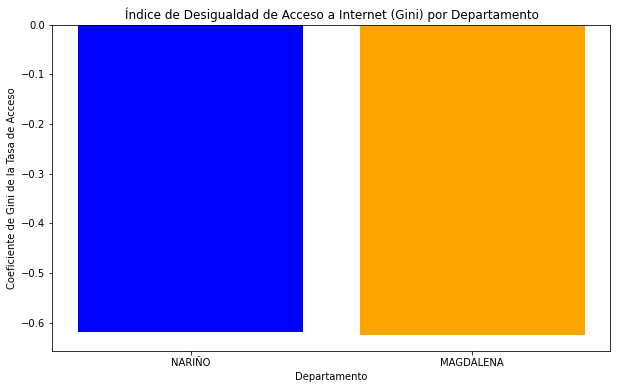

In [0]:
#Tercer paso: Gráficar
# Almacenar los nombres de los departamentos y sus valores de Gini para no usar "Pandas" y seguir el procedimiento como cuando se trata de Big Data
departamentos = ["NARIÑO", "MAGDALENA"]
gini_values = [gini_narino, gini_magdalena]

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(departamentos, gini_values, color=['blue', 'orange'])
plt.title("Índice de Desigualdad de Acceso a Internet (Gini) por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Coeficiente de Gini de la Tasa de Acceso")
plt.show()

Índice de desigualdad en acceso a internet en municipios del norte: 2.21
Índice de desigualdad en acceso a internet en municipios del sur: 2.41


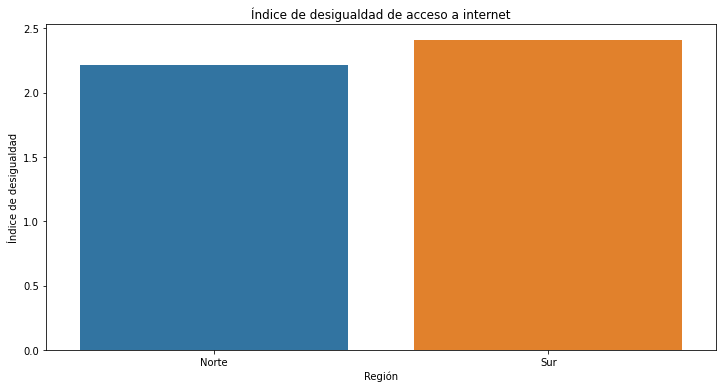

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Separar los municipios del norte y del sur
norte = df_Internet4.filter(F.col("DEPARTAMENTO").isin(["NARIÑO"]))
sur = df_Internet4.filter(F.col("DEPARTAMENTO").isin(["MAGDALENA"]))

# Calcular el índice de desigualdad para el norte
norte_accesos_por_100_habitantes = (norte
                                   .withColumn("ACCESOS_POR_100_HABITANTES", F.round(F.col("No_ACCESOS_FIJOS_A_INTERNET") * 100.0 / F.col("POBLACION_DANE"), 2))
                                   .select("MUNICIPIO", "ACCESOS_POR_100_HABITANTES"))
norte_promedio = norte_accesos_por_100_habitantes.agg(F.avg("ACCESOS_POR_100_HABITANTES").alias("PROMEDIO_NORTE")).collect()[0]["PROMEDIO_NORTE"]
norte_indice_desigualdad = (norte_accesos_por_100_habitantes
                            .withColumn("DIFERENCIA_PROMEDIO", F.col("ACCESOS_POR_100_HABITANTES") - norte_promedio)
                            .agg(F.round(F.avg(F.abs("DIFERENCIA_PROMEDIO")), 2).alias("INDICE_DESIGUALDAD_NORTE")))
print(f"Índice de desigualdad en acceso a internet en municipios del norte: {norte_indice_desigualdad.collect()[0]['INDICE_DESIGUALDAD_NORTE']}")

# Calcular el índice de desigualdad para el sur
sur_accesos_por_100_habitantes = (sur
                                  .withColumn("ACCESOS_POR_100_HABITANTES", F.round(F.col("No_ACCESOS_FIJOS_A_INTERNET") * 100.0 / F.col("POBLACION_DANE"), 2))
                                  .select("MUNICIPIO", "ACCESOS_POR_100_HABITANTES"))
sur_promedio = sur_accesos_por_100_habitantes.agg(F.avg("ACCESOS_POR_100_HABITANTES").alias("PROMEDIO_SUR")).collect()[0]["PROMEDIO_SUR"]
sur_indice_desigualdad = (sur_accesos_por_100_habitantes
                          .withColumn("DIFERENCIA_PROMEDIO", F.col("ACCESOS_POR_100_HABITANTES") - sur_promedio)
                          .agg(F.round(F.avg(F.abs("DIFERENCIA_PROMEDIO")), 2).alias("INDICE_DESIGUALDAD_SUR")))
print(f"Índice de desigualdad en acceso a internet en municipios del sur: {sur_indice_desigualdad.collect()[0]['INDICE_DESIGUALDAD_SUR']}")

# Graficar los resultados
plt.figure(figsize=(12, 6))
sns.barplot(x=["Norte", "Sur"], y=[norte_indice_desigualdad.collect()[0]['INDICE_DESIGUALDAD_NORTE'], 
                                   sur_indice_desigualdad.collect()[0]['INDICE_DESIGUALDAD_SUR']])
plt.title("Índice de desigualdad de acceso a internet")
plt.xlabel("Región")
plt.ylabel("Índice de desigualdad")
plt.show()


## Educación
### Preguntas:
1. ¿Cuál es el índice de cobertura neta en educación de los municipios seleccionados?
2. ¿Cuál es la variación en la taza de matriculación de colegios dependiendo del desarrollo económico del municipio? Sacar conclusiones.
### Procedimiento Pregunta 1
1. Seleccionar los municipios
2. Seleccionar las variables 
3. generar gráfico

### Procedimiento Pregunta 2
1. Seleccionar Municipios para el analisis
2. Calcular la tasa de matriculación en base a cada municipio - ciudad
3. Gráficar información del paso 1 y 2
4. Realizar analisis detallado para sacar las conclusiones

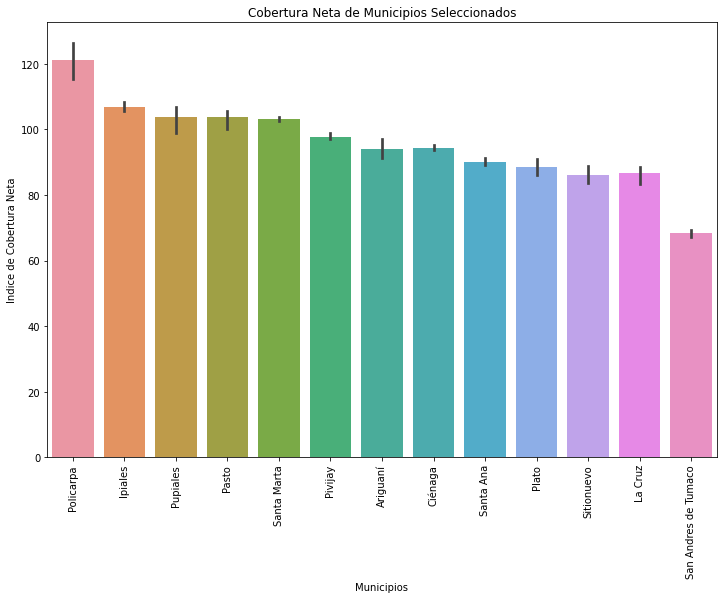

In [0]:
selected_municipalities = ["Santa Marta", "Santa Ana", "Plato", "Ariguaní", 
                           "Pivijay", "Ciénaga", "Sitionuevo", "Pasto",
                           "Pupiales", "San Andres de Tumaco", "Policarpa", "La Cruz",
                           "Ipiales", "La Union"]

chart_df = df_Educacion3.select("DEPARTAMENTO", "MUNICIPIO", "COBERTURA_NETA") \
                       .where(col("MUNICIPIO").isin(selected_municipalities)) \
                       .orderBy(col("COBERTURA_NETA").desc())

# Convert Spark DataFrame to Pandas DataFrame for visualization
pd_chart_df = chart_df.toPandas()

# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x="MUNICIPIO", y="COBERTURA_NETA", data=pd_chart_df, ax=ax)
ax.set_title("Cobertura Neta de Municipios Seleccionados")
ax.set_xlabel("Municipios")
ax.set_ylabel("Indice de Cobertura Neta")
plt.xticks(rotation=90)
plt.show()

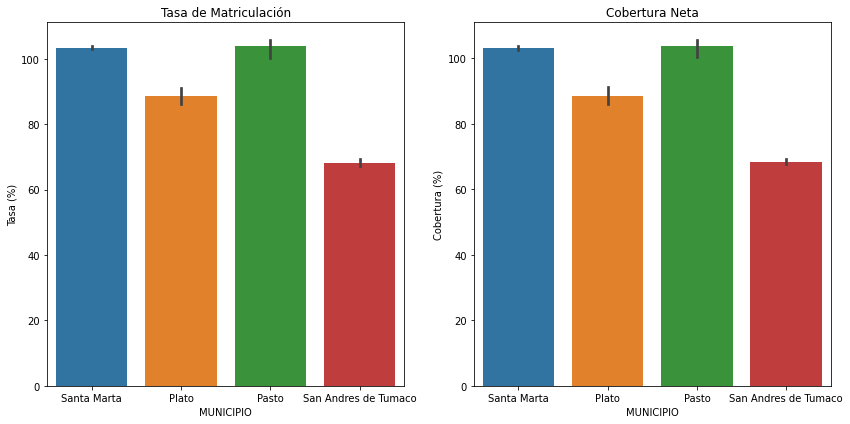


Estadísticas detalladas:
+--------------------+-----------+--------------+--------------------+
|MUNICIPIO           |TASA_M_5_16|COBERTURA_NETA|ECONOMIC_DEVELOPMENT|
+--------------------+-----------+--------------+--------------------+
|Santa Marta         |102.9      |102.57        |High                |
|Plato               |91.18      |91.13         |High                |
|Pasto               |105.24     |105.07        |High                |
|San Andres de Tumaco|67.18      |67.16         |Low                 |
|Santa Marta         |103.33     |102.97        |High                |
|Plato               |88.36      |88.36         |Medium              |
|Pasto               |105.89     |105.66        |High                |
|San Andres de Tumaco|68.47      |68.46         |Low                 |
|Santa Marta         |104.08     |103.7         |High                |
|Plato               |86.14      |86.12         |Medium              |
|Pasto               |100.41     |100.24        |Hi

In [0]:
#SEGUNDA PREGUNTA

# Filtrar solo Santa Marta, Plato, San Andres de Tumaco y Pasto del DataFrame df_Educacion3
selected_cities = df_Educacion3.filter(col("MUNICIPIO").isin(["Santa Marta", "Pasto", "San Andres de Tumaco", "Plato"]))

# Categorizar el desarrollo económico
selected_cities = selected_cities.withColumn("ECONOMIC_DEVELOPMENT",
                                           when(col("TASA_M_5_16") < 80, "Low")
                                           .when((col("TASA_M_5_16") >= 80) & (col("TASA_M_5_16") < 90), "Medium")
                                           .when(col("TASA_M_5_16") >= 90, "High")
                                           .otherwise("Unknown"))

# Crear un DataFrame con las métricas relevantes
comparison_df = selected_cities.select("MUNICIPIO", "TASA_M_5_16", "COBERTURA_NETA", "ECONOMIC_DEVELOPMENT")

# Convertir a Pandas para visualización
pd_comparison = comparison_df.toPandas()

# Crear gráfico de barras comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de Tasa de Matriculación
sns.barplot(x="MUNICIPIO", y="TASA_M_5_16", data=pd_comparison, ax=ax1)
ax1.set_title("Tasa de Matriculación")
ax1.set_ylabel("Tasa (%)")

# Gráfico de Cobertura Neta
sns.barplot(x="MUNICIPIO", y="COBERTURA_NETA", data=pd_comparison, ax=ax2)
ax2.set_title("Cobertura Neta")
ax2.set_ylabel("Cobertura (%)")

plt.tight_layout()
plt.show()

# Mostrar las estadísticas detalladas
print("\nEstadísticas detalladas:")
comparison_df.show(truncate=False)

In [0]:
# Análisis detallado por ciudad
city_analysis = selected_cities.groupBy("MUNICIPIO").agg({
    "TASA_M_5_16": "avg",
    "COBERTURA_NETA": "avg"
}).withColumnRenamed("avg(TASA_M_5_16)", "PROMEDIO_TASA_MATRICULACION") \
  .withColumnRenamed("avg(COBERTURA_NETA)", "PROMEDIO_COBERTURA_NETA")

# Mostrar análisis detallado
print("\nAnálisis comparativo:")
city_analysis.show(truncate=False)

# Calcular la diferencia porcentual entre las ciudades
city_analysis_pd = city_analysis.toPandas()
if len(city_analysis_pd) == 2:
    diff_matriculacion = abs(city_analysis_pd.iloc[0]["PROMEDIO_TASA_MATRICULACION"] - 
                           city_analysis_pd.iloc[1]["PROMEDIO_TASA_MATRICULACION"])
    diff_cobertura = abs(city_analysis_pd.iloc[0]["PROMEDIO_COBERTURA_NETA"] - 
                        city_analysis_pd.iloc[1]["PROMEDIO_COBERTURA_NETA"])
    
    print(f"\nDiferencia en Tasa de Matriculación: {diff_matriculacion:.2f}%")
    print(f"Diferencia en Cobertura Neta: {diff_cobertura:.2f}%")


Análisis comparativo:
+--------------------+---------------------------+-----------------------+
|MUNICIPIO           |PROMEDIO_TASA_MATRICULACION|PROMEDIO_COBERTURA_NETA|
+--------------------+---------------------------+-----------------------+
|Pasto               |103.84666666666665         |103.65666666666665     |
|Plato               |88.56                      |88.53666666666668      |
|San Andres de Tumaco|68.29666666666667          |68.28                  |
|Santa Marta         |103.43666666666667         |103.08                 |
+--------------------+---------------------------+-----------------------+



## ICFES SABER 11
### Pregunta:
¿Hay una diferencia significativa en la proyección económica según los resultados académicos, entre los municipios al norte del país respecto a los elegidos en el sur?

### Procedimiento:
1. Limpar los datos para que los valores nulos no sesguen la información
2. Se separan los municipios por departamento
3. Se calculan las estadisticas segun el puntaje global (contar, promedio, desviación) por región
4. Analisis de tratamiento de valores nulos
5. Gráficar los pasos anteriores

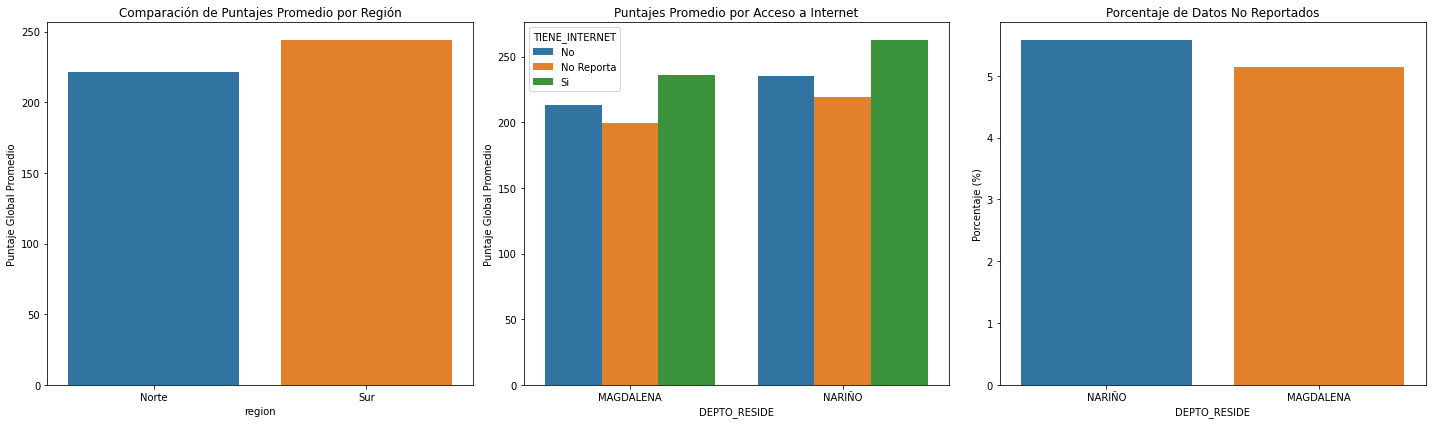


Estadísticas Detalladas por Región:
+-----------------+------------------+-------------------+------+
|total_estudiantes|          promedio|desviacion_estandar|region|
+-----------------+------------------+-------------------+------+
|            16627| 221.3298851266013| 45.752675601291855| Norte|
|            16903|244.31130568538129|  52.06152658686808|   Sur|
+-----------------+------------------+-------------------+------+


Análisis por Acceso a Internet:
+------------+--------------+------------------+--------------------+
|DEPTO_RESIDE|TIENE_INTERNET|  promedio_puntaje|cantidad_estudiantes|
+------------+--------------+------------------+--------------------+
|   MAGDALENA|          null| 203.0222222222222|                 315|
|   MAGDALENA|            No|212.80460164835165|                8736|
|   MAGDALENA|    No Reporta| 199.1791569086651|                 854|
|   MAGDALENA|            Si|  236.081523356144|                6722|
|      NARIÑO|          null|221.0563002680

In [0]:
# Limpieza de datos: unificar valores nulos
df_Saber4 = df_Saber3
df_clean = df_Saber4.withColumn(
    "TIENE_INTERNET",
    when(col("TIENE_INTERNET").isin([None, "null", "-"]), "No Reporta")
    .otherwise(col("TIENE_INTERNET"))
)

# Separar municipios por región
north_results = df_clean.filter(col("DEPTO_RESIDE") == "MAGDALENA")
south_results = df_clean.filter(col("DEPTO_RESIDE") == "NARIÑO")

def calculate_stats(df, region_name):
    return df.agg(
        count("PUNT_GLOBAL").alias("total_estudiantes"),
        avg("PUNT_GLOBAL").alias("promedio"),
        stddev("PUNT_GLOBAL").alias("desviacion_estandar")
    ).withColumn("region", lit(region_name))

# Calcular estadísticas por región
north_stats = calculate_stats(north_results, "Norte")
south_stats = calculate_stats(south_results, "Sur")
stats_comparison = north_stats.union(south_stats)

# Análisis por acceso a internet con tratamiento de nulos
internet_analysis = df_clean.groupBy("DEPTO_RESIDE", "TIENE_INTERNET") \
    .agg(
        avg("PUNT_GLOBAL").alias("promedio_puntaje"),
        count("*").alias("cantidad_estudiantes")
    ) \
    .orderBy("DEPTO_RESIDE", "TIENE_INTERNET")

# Análisis adicional: proporción de datos faltantes
missing_data_analysis = df_clean.groupBy("DEPTO_RESIDE") \
    .agg(
        count(when(col("TIENE_INTERNET") == "No Reporta", True)).alias("datos_no_reportados"),
        count("*").alias("total_registros")
    ) \
    .withColumn(
        "porcentaje_no_reportado",
        (col("datos_no_reportados") * 100 / col("total_registros"))
    )

# Convertir a Pandas para visualización
pd_stats = stats_comparison.toPandas()
pd_internet = internet_analysis.toPandas()
pd_missing = missing_data_analysis.toPandas()

# Crear visualizaciones
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Comparación de puntajes promedio
sns.barplot(x="region", y="promedio", data=pd_stats, ax=ax1)
ax1.set_title("Comparación de Puntajes Promedio por Región")
ax1.set_ylabel("Puntaje Global Promedio")

# Gráfico 2: Puntajes por acceso a internet
sns.barplot(x="DEPTO_RESIDE", y="promedio_puntaje", hue="TIENE_INTERNET", data=pd_internet, ax=ax2)
ax2.set_title("Puntajes Promedio por Acceso a Internet")
ax2.set_ylabel("Puntaje Global Promedio")

# Gráfico 3: Proporción de datos faltantes
sns.barplot(x="DEPTO_RESIDE", y="porcentaje_no_reportado", data=pd_missing, ax=ax3)
ax3.set_title("Porcentaje de Datos No Reportados")
ax3.set_ylabel("Porcentaje (%)")

plt.tight_layout()
plt.show()

# Mostrar estadísticas detalladas
print("\nEstadísticas Detalladas por Región:")
stats_comparison.show()

print("\nAnálisis por Acceso a Internet:")
internet_analysis.show()

print("\nAnálisis de Datos No Reportados:")
missing_data_analysis.show()

## Educación vs Internet
### Pregunta: 
¿Cómo afectan los resultados académicos y la formación estudiantil, la frecuencia al acceso a internet y las diferentes herramientas tecnológicas presentes en los establecimientos académicos?

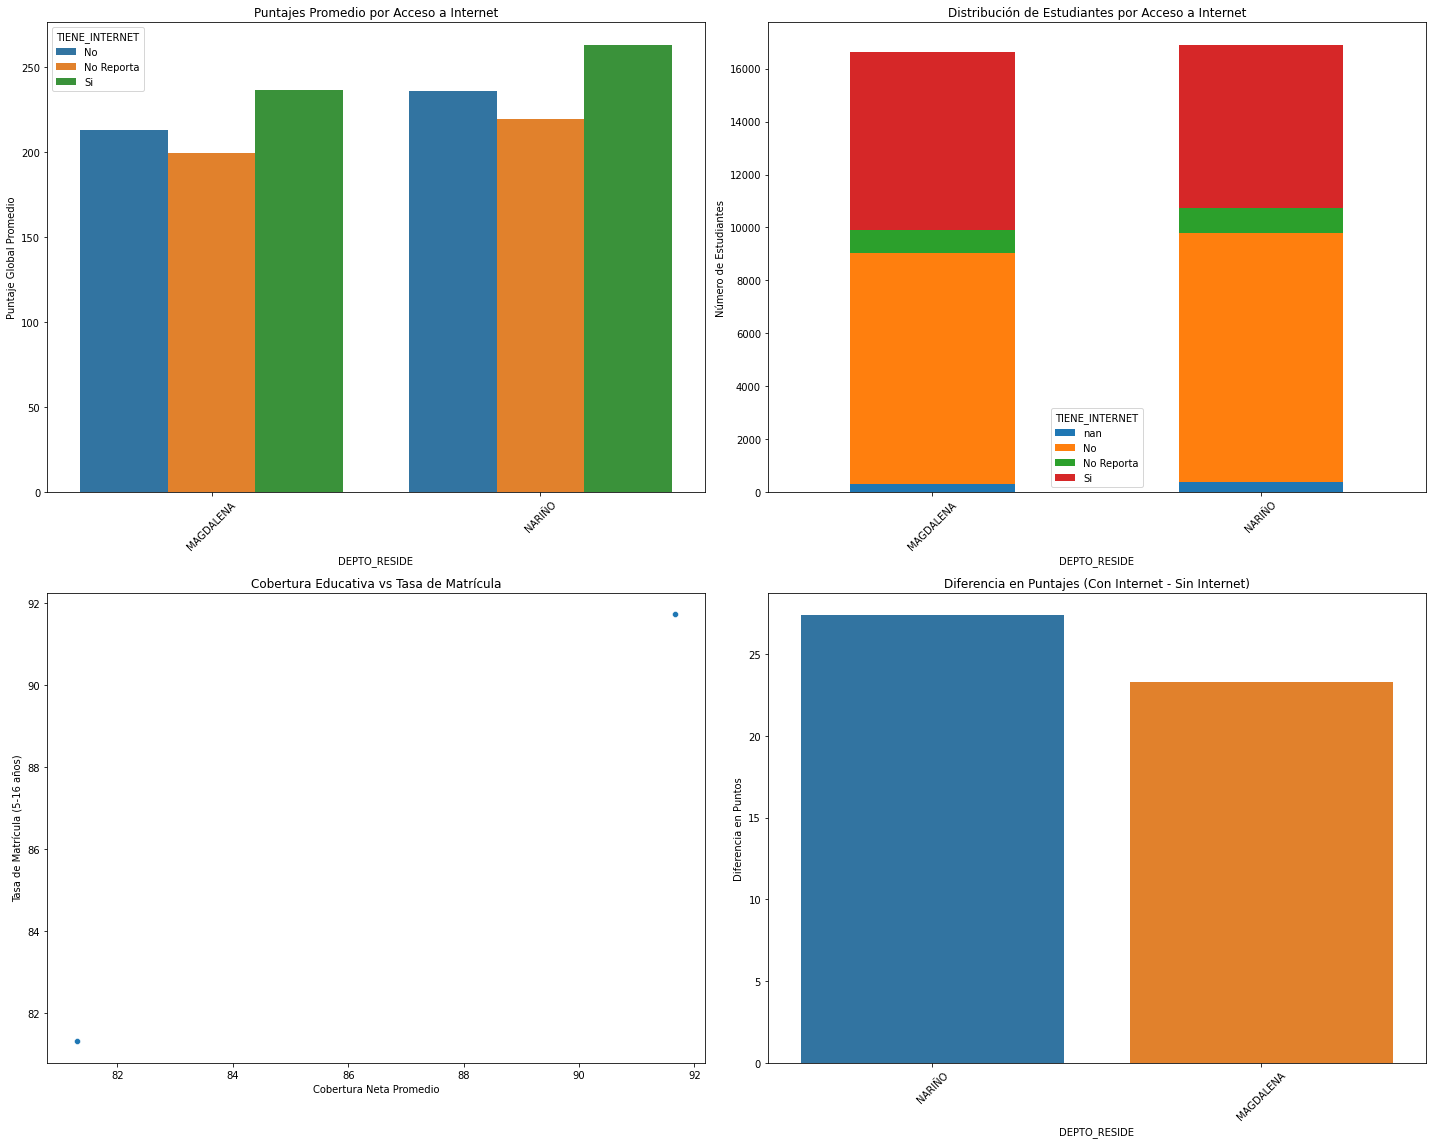


Estadísticas por Acceso a Internet:
+------------+--------------+----------------+--------------------+
|DEPTO_RESIDE|TIENE_INTERNET|promedio_puntaje|cantidad_estudiantes|
+------------+--------------+----------------+--------------------+
|   MAGDALENA|          null|          203.02|                 315|
|   MAGDALENA|            No|           212.8|                8736|
|   MAGDALENA|    No Reporta|          199.18|                 854|
|   MAGDALENA|            Si|          236.08|                6722|
|      NARIÑO|          null|          221.06|                 373|
|      NARIÑO|            No|          235.56|                9432|
|      NARIÑO|    No Reporta|          219.42|                 944|
|      NARIÑO|            Si|          262.95|                6154|
+------------+--------------+----------------+--------------------+


Métricas Educativas por Departamento:
+------------+------------------+-----------------------+
|DEPARTAMENTO|cobertura_promedio|tasa_matricula_p

In [0]:
# 1. Limpieza y preparación de datos
# Estandarizar valores nulos en df_Saber
df_Saber4_clean = df_Saber4.withColumn(
    "TIENE_INTERNET",
    when(col("TIENE_INTERNET").isin([None, "null", "-"]), "No Reporta")
    .otherwise(col("TIENE_INTERNET"))
)

# 2. Análisis de resultados académicos por acceso a internet
internet_analysis = df_Saber4_clean.groupBy("DEPTO_RESIDE", "TIENE_INTERNET") \
    .agg(
        round(avg("PUNT_GLOBAL"), 2).alias("promedio_puntaje"),
        count("*").alias("cantidad_estudiantes")
    ) \
    .orderBy("DEPTO_RESIDE", "TIENE_INTERNET")

# 3. Análisis de cobertura educativa y resultados
education_metrics = df_Educacion3.groupBy("DEPARTAMENTO") \
    .agg(
        round(avg("COBERTURA_NETA"), 2).alias("cobertura_promedio"),
        round(avg("TASA_M_5_16"), 2).alias("tasa_matricula_promedio")
    )

# 4. Análisis combinado
# Calculamos la diferencia de puntaje entre estudiantes con y sin internet
internet_impact = df_Saber4_clean \
    .filter(col("TIENE_INTERNET").isin(["Si", "No"])) \
    .groupBy("DEPTO_RESIDE") \
    .pivot("TIENE_INTERNET") \
    .agg(avg("PUNT_GLOBAL")) \
    .withColumn("diferencia_puntaje", col("Si") - col("No"))

# 5. Visualizaciones
# Convertir a Pandas para visualización
pd_internet = internet_analysis.toPandas()
pd_education = education_metrics.toPandas()
pd_impact = internet_impact.toPandas()

# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Gráfico 1: Puntajes por acceso a internet
sns.barplot(x="DEPTO_RESIDE", y="promedio_puntaje", 
            hue="TIENE_INTERNET", data=pd_internet, ax=axes[0,0])
axes[0,0].set_title("Puntajes Promedio por Acceso a Internet")
axes[0,0].set_ylabel("Puntaje Global Promedio")
axes[0,0].tick_params(axis='x', rotation=45)

# Gráfico 2: Distribución de estudiantes por acceso a internet
internet_dist = pd_internet.pivot(index='DEPTO_RESIDE', 
                                columns='TIENE_INTERNET', 
                                values='cantidad_estudiantes')
internet_dist.plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title("Distribución de Estudiantes por Acceso a Internet")
axes[0,1].set_ylabel("Número de Estudiantes")
axes[0,1].tick_params(axis='x', rotation=45)

# Gráfico 3: Cobertura educativa vs Tasa de matrícula
sns.scatterplot(data=pd_education, 
                x="cobertura_promedio", 
                y="tasa_matricula_promedio", 
                ax=axes[1,0])
axes[1,0].set_title("Cobertura Educativa vs Tasa de Matrícula")
axes[1,0].set_xlabel("Cobertura Neta Promedio")
axes[1,0].set_ylabel("Tasa de Matrícula (5-16 años)")

# Gráfico 4: Impacto del internet en puntajes
sns.barplot(data=pd_impact, 
            x="DEPTO_RESIDE", 
            y="diferencia_puntaje", 
            ax=axes[1,1])
axes[1,1].set_title("Diferencia en Puntajes (Con Internet - Sin Internet)")
axes[1,1].set_ylabel("Diferencia en Puntos")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Mostrar estadísticas detalladas
print("\nEstadísticas por Acceso a Internet:")
internet_analysis.show()

print("\nMétricas Educativas por Departamento:")
education_metrics.show()

print("\nImpacto del Internet en Puntajes:")
internet_impact.show()

# Selección Técnicas de Supervisión de Aprendizaje de Maquina
## Técnica de aprendizaje de máquina supervisado 
## Técnica de aprendizaje de máquina no supervisado

Preparando datos para Random Forest...
Entrenando Random Forest...
Preparando datos para K-means...
Entrenando K-means...
Creando visualizaciones...
Generando análisis...
=== Resultados del Análisis ===

1. Random Forest:
Precisión del modelo: 61.12%

2. Análisis de Clusters:
+----------+-------------------+------------------+--------------------+
|prediction|cantidad_municipios|  puntaje_promedio|tasa_acceso_promedio|
+----------+-------------------+------------------+--------------------+
|         0|                627| 256.7957343541517|0.030548532668073735|
|         1|                437|199.85349003106083|  0.0098490996037098|
|         2|                589|228.27024310658064|  0.0323925262394483|
+----------+-------------------+------------------+--------------------+



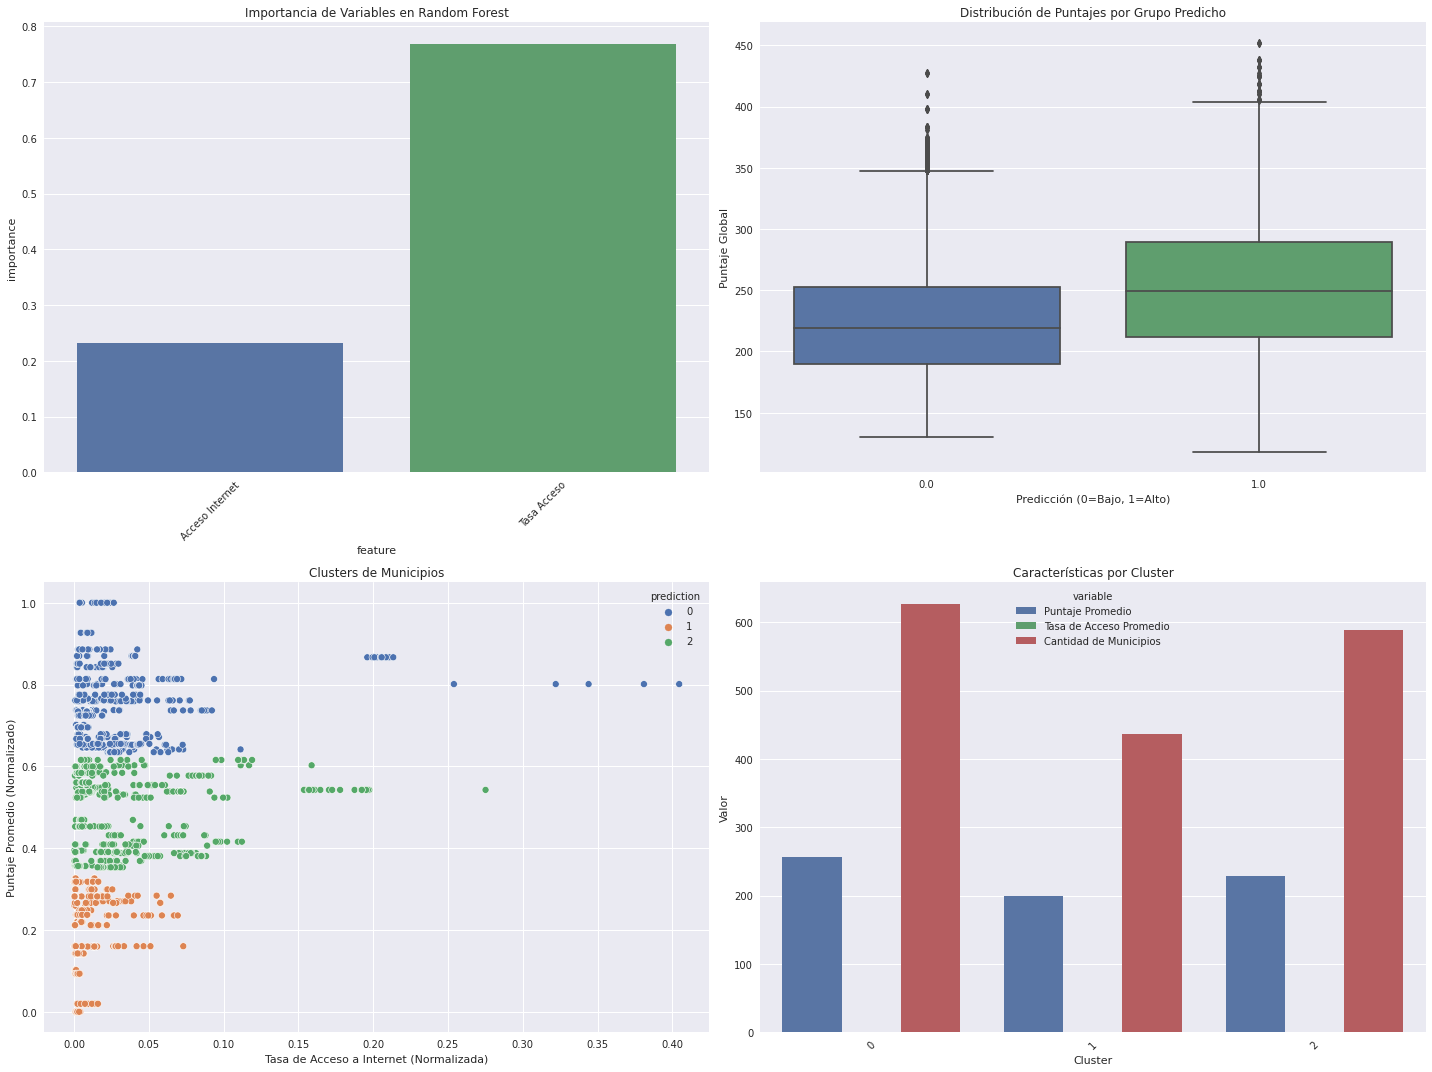

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def prepare_data_for_rf(df_Internet4, df_Saber4):
    """Prepara los datos para Random Forest manejando valores nulos"""
    # Limpiamos los datos primero
    df_Saber4_clean = df_Saber4.filter(
        (F.col("TIENE_INTERNET").isNotNull()) &
        (F.col("PUNT_GLOBAL").isNotNull()) &
        (F.col("TIENE_INTERNET") != "-")
    )
    
    # Convertir TIENE_INTERNET a numérico directamente
    df_Saber4_clean = df_Saber4_clean.withColumn(
        "internet_numeric",
        F.when(F.col("TIENE_INTERNET") == "Si", 1.0)
        .otherwise(0.0)
    )
    
    # Unir los dataframes por municipio
    df_joined = df_Saber4_clean.join(
        df_Internet4,
        (df_Saber4_clean.MCPIO_RESIDE == df_Internet4.MUNICIPIO) &
        (df_Saber4_clean.DEPTO_RESIDE == df_Internet4.DEPARTAMENTO),
        'inner'  # Cambiamos a inner join para asegurar correspondencia
    )
    
    # Crear variable objetivo binaria (alto/bajo rendimiento)
    median_score = df_joined.approxQuantile("PUNT_GLOBAL", [0.5], 0.01)[0]
    df_joined = df_joined.withColumn(
        "high_performance",
        F.when(F.col("PUNT_GLOBAL") > median_score, 1.0).otherwise(0.0)
    )
    
    # Preparar features sin usar StringIndexer
    feature_cols = ["internet_numeric", "tasa_acceso"]
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    final_data = assembler.transform(df_joined)
    
    return final_data.select("features", "high_performance", "PUNT_GLOBAL")

def train_random_forest(prepared_data):
    """Entrena el modelo Random Forest"""
    # Dividir datos
    train_data, test_data = prepared_data.randomSplit([0.8, 0.2], seed=42)
    
    # Entrenar modelo
    rf = RandomForestClassifier(
        labelCol="high_performance",
        featuresCol="features",
        numTrees=50,  # Reducimos el número de árboles para mayor eficiencia
        maxDepth=5
    )
    model = rf.fit(train_data)
    
    # Evaluar modelo
    predictions = model.transform(test_data)
    evaluator = MulticlassClassificationEvaluator(
        labelCol="high_performance",
        predictionCol="prediction",
        metricName="accuracy"
    )
    accuracy = evaluator.evaluate(predictions)
    
    return model, predictions, accuracy

def prepare_data_for_kmeans(df_Internet4, df_Saber4):
    """Prepara los datos para K-means"""
    # Limpiamos los datos primero
    df_Saber4_clean = df_Saber4.filter(
        F.col("PUNT_GLOBAL").isNotNull()
    )
    
    # Agregar estadísticas por municipio
    stats_by_municipality = df_Saber4_clean.groupBy(
        "MCPIO_RESIDE", "DEPTO_RESIDE"
    ).agg(
        F.avg("PUNT_GLOBAL").alias("avg_score"),
        F.count("*").alias("student_count")
    )
    
    # Unir con datos de internet
    df_merged = stats_by_municipality.join(
        df_Internet4,
        (stats_by_municipality.MCPIO_RESIDE == df_Internet4.MUNICIPIO) &
        (stats_by_municipality.DEPTO_RESIDE == df_Internet4.DEPARTAMENTO),
        'inner'
    )
    
    # Crear ventana para todo el dataset
    windowSpec = Window.partitionBy()
    
    # Normalizar las características usando la ventana
    df_merged = df_merged.withColumn(
        "normalized_score",
        (F.col("avg_score") - F.min("avg_score").over(windowSpec)) / 
        (F.max("avg_score").over(windowSpec) - F.min("avg_score").over(windowSpec))
    ).withColumn(
        "normalized_access",
        F.col("tasa_acceso")  # Ya está en proporción
    )
    
    # Preparar features para clustering
    assembler = VectorAssembler(
        inputCols=["normalized_score", "normalized_access"],
        outputCol="features"
    )
    
    return assembler.transform(df_merged)


def create_visualizations(rf_model, rf_predictions, kmeans_model, cluster_predictions):
    """Crea visualizaciones para ambos modelos"""
    plt.style.use('seaborn')
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Importancia de características (Random Forest)
    ax1 = plt.subplot(2, 2, 1)
    feature_importance = pd.DataFrame({
        'feature': ['Acceso Internet', 'Tasa Acceso'],
        'importance': rf_model.featureImportances.toArray()
    })
    sns.barplot(
        data=feature_importance,
        x='feature',
        y='importance',
        ax=ax1
    )
    ax1.set_title('Importancia de Variables en Random Forest')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    
    # 2. Distribución de Puntajes por Predicción
    ax2 = plt.subplot(2, 2, 2)
    predictions_pd = rf_predictions.select('prediction', 'PUNT_GLOBAL').toPandas()
    sns.boxplot(
        data=predictions_pd,
        x='prediction',
        y='PUNT_GLOBAL',
        ax=ax2
    )
    ax2.set_title('Distribución de Puntajes por Grupo Predicho')
    ax2.set_xlabel('Predicción (0=Bajo, 1=Alto)')
    ax2.set_ylabel('Puntaje Global')
    
    # 3. Visualización de Clusters
    ax3 = plt.subplot(2, 2, 3)
    cluster_data_pd = cluster_predictions.select(
        'normalized_score',
        'normalized_access',
        'prediction'
    ).toPandas()
    
    sns.scatterplot(
        data=cluster_data_pd,
        x='normalized_access',
        y='normalized_score',
        hue='prediction',
        palette='deep',
        ax=ax3
    )
    ax3.set_title('Clusters de Municipios')
    ax3.set_xlabel('Tasa de Acceso a Internet (Normalizada)')
    ax3.set_ylabel('Puntaje Promedio (Normalizado)')
    
    # 4. Características de Clusters
    ax4 = plt.subplot(2, 2, 4)
    cluster_stats = cluster_predictions.groupBy('prediction').agg(
        F.avg('avg_score').alias('Puntaje Promedio'),
        F.avg('tasa_acceso').alias('Tasa de Acceso Promedio'),
        F.count('*').alias('Cantidad de Municipios')
    ).toPandas()
    
    sns.barplot(
        data=pd.melt(cluster_stats, id_vars=['prediction']),
        x='prediction',
        y='value',
        hue='variable',
        ax=ax4
    )
    ax4.set_title('Características por Cluster')
    ax4.set_xlabel('Cluster')
    ax4.set_ylabel('Valor')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    return fig

def print_analysis(rf_accuracy, cluster_predictions):
    """Imprime análisis detallado de los resultados"""
    print("=== Resultados del Análisis ===")
    print(f"\n1. Random Forest:")
    print(f"Precisión del modelo: {rf_accuracy:.2%}")
    
    print("\n2. Análisis de Clusters:")
    cluster_predictions.groupBy('prediction').agg(
        F.count('*').alias('cantidad_municipios'),
        F.avg('avg_score').alias('puntaje_promedio'),
        F.avg('tasa_acceso').alias('tasa_acceso_promedio')
    ).orderBy('prediction').show()

def run_complete_analysis(df_Internet4, df_Saber4):
    """Ejecuta el análisis completo"""
    print("Preparando datos para Random Forest...")
    rf_data = prepare_data_for_rf(df_Internet4, df_Saber4)
    
    print("Entrenando Random Forest...")
    rf_model, rf_predictions, rf_accuracy = train_random_forest(rf_data)
    
    print("Preparando datos para K-means...")
    kmeans_data = prepare_data_for_kmeans(df_Internet4, df_Saber4)
    
    print("Entrenando K-means...")
    kmeans = KMeans(k=3, seed=42)
    kmeans_model = kmeans.fit(kmeans_data)
    cluster_predictions = kmeans_model.transform(kmeans_data)
    
    print("Creando visualizaciones...")
    fig = create_visualizations(rf_model, rf_predictions, kmeans_model, cluster_predictions)
    
    print("Generando análisis...")
    print_analysis(rf_accuracy, cluster_predictions)
    
    return fig, rf_model, kmeans_model

# Ejecutar el análisis
fig, rf_model, kmeans_model = run_complete_analysis(df_Internet4, df_Saber4)
plt.show()

# Preparación de datos para el modelado
## Eliminar características fuertemente correlacionadas: 
en este apartado se espera que se calcule la correlación entre las variables y se eliminen aquellas fuertemente correlacionadas si es el caso.
## Normalización de variables numéricas: 
en este apartado se espera que se realice unanormalización de datos si es el caso.
## Selección de variables según criterio de negocio: 
en este apartado se espera que se describa el grupo de variables que se usaran para la construcción de las técnicas seleccionadas.

### ELIMINAR CARACTERÌSTICAS FUERTEMENTE CORRELACIONADAS

In [0]:
import pandas as pd
import numpy as np

# nombres de las columnas numéricas
numeric_columns = [col for col, dtype in df_Internet4.dtypes if dtype in ('double', 'int')]

#Calcula la matriz de correlación para cada par de columnas
correlation_matrix = {}
for col1 in numeric_columns:
    correlation_matrix[col1] = []
    for col2 in numeric_columns:
        corr_value = df_Internet4.stat.corr(col1, col2)
        correlation_matrix[col1].append(corr_value)

#Convierte la matriz a un DataFrame de pandas para facilitar su manipulación
correlation_matrix_df = pd.DataFrame(correlation_matrix, index=numeric_columns, columns=numeric_columns)




In [0]:
# Seleccionar pares de características con alta correlación
upper_triangle = correlation_matrix_df.where(np.triu(np.ones(correlation_matrix_df.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]

# Eliminar características correlacionadas
df_Internet4 = df_Internet4.drop(*high_corr_features)

print("Características eliminadas debido a alta correlación:", high_corr_features)

Características eliminadas debido a alta correlación: ['POBLACION_DANE']


In [0]:
import pandas as pd
import numpy as np
# nombres de las columnas numéricas
numeric_columns = [col for col, dtype in df_Educacion3.dtypes if dtype in ('double', 'int')]

#Calcula la matriz de correlación para cada par de columnas
correlation_matrix = {}
for col1 in numeric_columns:
    correlation_matrix[col1] = []
    for col2 in numeric_columns:
        corr_value = df_Educacion3.stat.corr(col1, col2)
        correlation_matrix[col1].append(corr_value)

#Convierte la matriz a un DataFrame de pandas para facilitar su manipulación
correlation_matrix_df = pd.DataFrame(correlation_matrix, index=numeric_columns, columns=numeric_columns)

In [0]:
# Seleccionar pares de características con alta correlación
upper_triangle = correlation_matrix_df.where(np.triu(np.ones(correlation_matrix_df.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]

# Eliminar características correlacionadas
df_Educacion3 = df_Educacion3.drop(*high_corr_features)

print("Características eliminadas debido a alta correlación:", high_corr_features)

Características eliminadas debido a alta correlación: ['COBERTURA_NETA']


In [0]:
import pandas as pd
import numpy as np
# nombres de las columnas numéricas
numeric_columns = [col for col, dtype in df_Saber4.dtypes if dtype in ('double', 'int')]

#Calcula la matriz de correlación para cada par de columnas
correlation_matrix = {}
for col1 in numeric_columns:
    correlation_matrix[col1] = []
    for col2 in numeric_columns:
        corr_value = df_Saber4.stat.corr(col1, col2)
        correlation_matrix[col1].append(corr_value)

#Convierte la matriz a un DataFrame de pandas para facilitar su manipulación
correlation_matrix_df = pd.DataFrame(correlation_matrix, index=numeric_columns, columns=numeric_columns)

In [0]:
# Seleccionar pares de características con alta correlación
upper_triangle = correlation_matrix_df.where(np.triu(np.ones(correlation_matrix_df.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]

# Eliminar características correlacionadas
df_Saber4 = df_Saber4.drop(*high_corr_features)

print("Características eliminadas debido a alta correlación:", high_corr_features)

Características eliminadas debido a alta correlación: []


### NORMALIZACIÒN DE VARIABLES NUMÈRICAS

In [0]:
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

# Seleccionar nombres de columnas numéricas
numeric_columns = [col for col, dtype in df_Saber4.dtypes if dtype in ('double', 'int')]

# Paso 2: Transformar las columnas numéricas en un vector
assembler = VectorAssembler(inputCols=numeric_columns, outputCol="numeric_features")
df_vector = assembler.transform(df_Saber4)

# Paso 3: Aplicar MinMaxScaler
scaler = MinMaxScaler(inputCol="numeric_features", outputCol="scaled_features")
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# Paso 4: Convertir el vector "scaled_features" a un array para extraer los valores escalados
df_scaled = df_scaled.withColumn("scaled_features_array", vector_to_array("scaled_features"))

# Paso 5: Separar las columnas escaladas
for i, col_name in enumerate(numeric_columns):
    df_scaled = df_scaled.withColumn(f"{col_name}_scaled", F.col("scaled_features_array")[i])

# Opcional: Eliminar las columnas intermedias
df_scaled = df_scaled.drop("numeric_features", "scaled_features", "scaled_features_array")

print(f"1. Columnas numéricas seleccionadas: {numeric_columns}")

1. Columnas numéricas seleccionadas: ['PUNT_GLOBAL']
2. Ensamblaje de columnas numéricas en un vector para normalización.
3. Aplicación de MinMaxScaler para escalar valores en un rango de 0 a 1.
4. Las columnas normalizadas fueron añadidas con el sufijo '_scaled'.


In [0]:
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

# Seleccionar nombres de columnas numéricas
numeric_columns = [col for col, dtype in df_Internet4.dtypes if dtype in ('double', 'int')]

# Paso 2: Transformar las columnas numéricas en un vector
assembler = VectorAssembler(inputCols=numeric_columns, outputCol="numeric_features")
df_vector = assembler.transform(df_Internet4)

# Paso 3: Aplicar MinMaxScaler
scaler = MinMaxScaler(inputCol="numeric_features", outputCol="scaled_features")
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# Paso 4: Convertir el vector "scaled_features" a un array para extraer los valores escalados
df_scaled = df_scaled.withColumn("scaled_features_array", vector_to_array("scaled_features"))

# Paso 5: Separar las columnas escaladas
for i, col_name in enumerate(numeric_columns):
    df_scaled = df_scaled.withColumn(f"{col_name}_scaled", F.col("scaled_features_array")[i])

# Opcional: Eliminar las columnas intermedias
df_scaled = df_scaled.drop("numeric_features", "scaled_features", "scaled_features_array")

print(f"1. Columnas numéricas seleccionadas: {numeric_columns}")

1. Columnas numéricas seleccionadas: ['ANIO', 'No_ACCESOS_FIJOS_A_INTERNET', 'tasa_acceso']


### Selecciòn de variables segùn entorno de negocio
Para esta secciòn decidimos dejar las variables que se encuentran en el momento completas pues son pocas y las que hay son necesarias para el anàlisis de los datos por el momento
